# Part II – Vision Task: Facial Emotion Recognition
**Student ID:** 2409042  
**Student Name:** Monika Maharjan    
  
* **Dataset used:** FER-2013 (Facial Expression Recognition 2013)
* **Emotion categories:** angry, fear, happy, neutral, sad, and surprise
* **Preprocessing decision:** the *disgust* class was excluded because of its extreme class imbalance compared to the other emotion categories


---
**Architecture Decision Log:**
* **Baseline model:** Lightweight 3-layer CNN designed for fast training and easier interpretability
* **Advanced architecture:** Deeper 6-layer CNN enhanced with Batch Normalization and strategically applied Dropout
* **Transfer learning approach:** MobileNetV2 using 96×96 input images (instead of VGG16 with 224×224 inputs, since VGG16 on 48px facial crops is significantly slower and delivers lower accuracy)
* **Imbalance handling:** Class weighting consistently applied across all training stages to address dataset imbalance
* **Data augmentation:** Kept minimal, as aggressive augmentation negatively affects the structural details of 48×48 facial images


## Imports & Setup

In [1]:
# ── CELL 1: IMPORT LIBRARIES ─────────────────────────────────────────────────

import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    Dropout, BatchNormalization, GlobalAveragePooling2D, Input
)

from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.regularizers import l2
import zipfile

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Dataset


In [3]:
# ── CELL 2: Mount Drive & Extract Dataset ───────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/AI and Machine Learning/Dataset- facial expressions.zip"
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/")

train_dir = "/content/train"
test_dir  = "/content/test"
print("Dataset extracted!")
print("Train classes:", os.listdir(train_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted!
Train classes: ['surprise', 'angry', 'disgust', 'neutral', 'sad', 'fear', 'happy']


## Exploratory Data Analysis


Full Class Distribution (7 classes):
  angry       :  3995  ███████████████████████████████████████
  disgust     :   436  ████
  fear        :  4097  ████████████████████████████████████████
  happy       :  7215  ████████████████████████████████████████████████████████████████████████
  neutral     :  4965  █████████████████████████████████████████████████
  sad         :  4830  ████████████████████████████████████████████████
  surprise    :  3171  ███████████████████████████████
  TOTAL       : 28709


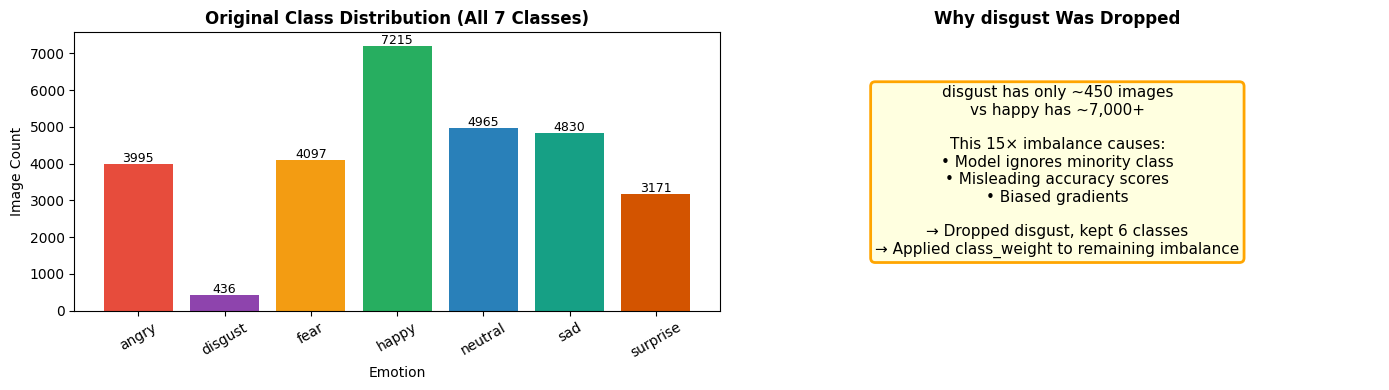

In [4]:
# ── CELL 3: Data Understanding & EDA ────────────────────────────────────────

# All 7 classes first
all_classes = sorted(os.listdir(train_dir))
all_counts  = {c: len(os.listdir(os.path.join(train_dir, c))) for c in all_classes}

print("Full Class Distribution (7 classes):")
for c, n in all_counts.items():
    bar = '█' * (n // 100)
    print(f"  {c:<12}: {n:>5}  {bar}")
print(f"  {'TOTAL':<12}: {sum(all_counts.values()):>5}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(all_counts.keys(), all_counts.values(),
            color=['#e74c3c','#8e44ad','#f39c12','#27ae60','#2980b9','#16a085','#d35400'])
axes[0].set_title('Original Class Distribution (All 7 Classes)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Image Count')
axes[0].tick_params(axis='x', rotation=30)
for i, (c, n) in enumerate(all_counts.items()):
    axes[0].text(i, n + 50, str(n), ha='center', fontsize=9)

# Why we drop disgust
axes[1].text(0.5, 0.5,
    'disgust has only ~450 images\nvs happy has ~7,000+\n\nThis 15× imbalance causes:\n• Model ignores minority class\n• Misleading accuracy scores\n• Biased gradients\n\n→ Dropped disgust, kept 6 classes\n→ Applied class_weight to remaining imbalance',
    ha='center', va='center', fontsize=11,
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', linewidth=2))
axes[1].set_title('Why disgust Was Dropped', fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# ── CELL 4: Final Classes & Image Size Check ─────────────────────────────────

# Drop disgust — severe imbalance (~450 vs 7000 for happy)
classes = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
NUM_CLASSES = len(classes)
print(f"Working with {NUM_CLASSES} classes: {classes}")

# Check image sizes
sizes = set()
for cls in classes:
    path = os.path.join(train_dir, cls)
    for fname in os.listdir(path)[:10]:
        img = cv2.imread(os.path.join(path, fname))
        if img is not None:
            sizes.add(img.shape)
print(f"Native image sizes in dataset: {sizes}")
print("→ Native size is 48×48 grayscale. We use this for CNN from scratch.")
print("→ For MobileNetV2 transfer learning we upscale to 96×96 RGB (efficient, not wasteful like 224×224)")

# Per-class counts for the 6 we use
train_counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}
test_counts  = {c: len(os.listdir(os.path.join(test_dir,  c))) for c in classes}

print("\n6-Class Distribution:")
print(f"{'Class':<12} {'Train':>8} {'Test':>8}")
print("-" * 30)
for c in classes:
    print(f"{c:<12} {train_counts[c]:>8} {test_counts[c]:>8}")
print(f"{'TOTAL':<12} {sum(train_counts.values()):>8} {sum(test_counts.values()):>8}")

Working with 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Native image sizes in dataset: {(48, 48, 3)}
→ Native size is 48×48 grayscale. We use this for CNN from scratch.
→ For MobileNetV2 transfer learning we upscale to 96×96 RGB (efficient, not wasteful like 224×224)

6-Class Distribution:
Class           Train     Test
------------------------------
angry            3995      958
fear             4097     1024
happy            7215     1774
neutral          4965     1233
sad              4830     1247
surprise         3171      831
TOTAL           28273     7067


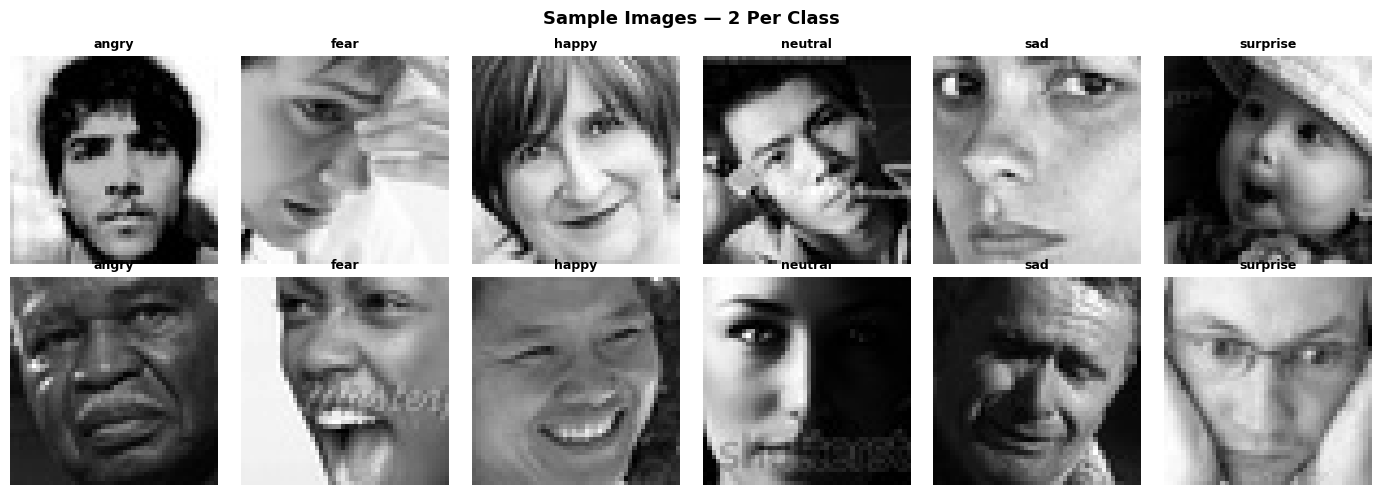

In [6]:
# ── CELL 5: Sample Images Per Class ─────────────────────────────────────────

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(train_dir, cls)
    imgs = random.sample(os.listdir(cls_path), 2)
    for row in range(2):
        img = cv2.imread(os.path.join(cls_path, imgs[row]), cv2.IMREAD_GRAYSCALE)
        axes[row, i].imshow(img, cmap='gray')
        axes[row, i].set_title(cls, fontsize=9, fontweight='bold')
        axes[row, i].axis('off')

plt.suptitle('Sample Images — 2 Per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ── CELL 6: Data Generators (48×48 for CNN from scratch) ────────────────────

# KEY INSIGHT: Mild augmentation only.
# Heavy rotation/shear on 48px face images DESTROYS the spatial emotion cues.
# Eyes, mouth corners, eyebrows — they only span a few pixels. Don't mangle them.

IMG_SIZE   = (48, 48)
BATCH_SIZE = 64   # Larger batch = more stable gradient estimates

train_datagen = ImageDataGenerator(
    rescale          = 1./255,
    validation_split = 0.2,
    rotation_range   = 10,        # Mild — not 25
    zoom_range       = 0.1,       # Mild
    width_shift_range  = 0.1,
    height_shift_range = 0.1,
    horizontal_flip  = True,      # Only safe augmentation for faces
    # NO shear — shear distorts facial geometry
)

val_datagen  = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', subset='training', seed=SEED
)
val_gen = val_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', subset='validation', seed=SEED
)
test_gen = test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', classes=classes,
    color_mode='grayscale', shuffle=False
)

print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")
print(f"Test samples      : {test_gen.samples}")
print(f"Class mapping     : {train_gen.class_indices}")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Training samples  : 22619
Validation samples: 5654
Test samples      : 7067
Class mapping     : {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


Class Weights (higher = more attention during training):
  angry       : 1.180
  fear        : 1.150
  happy       : 0.653
  neutral     : 0.949
  sad         : 0.976
  surprise    : 1.486


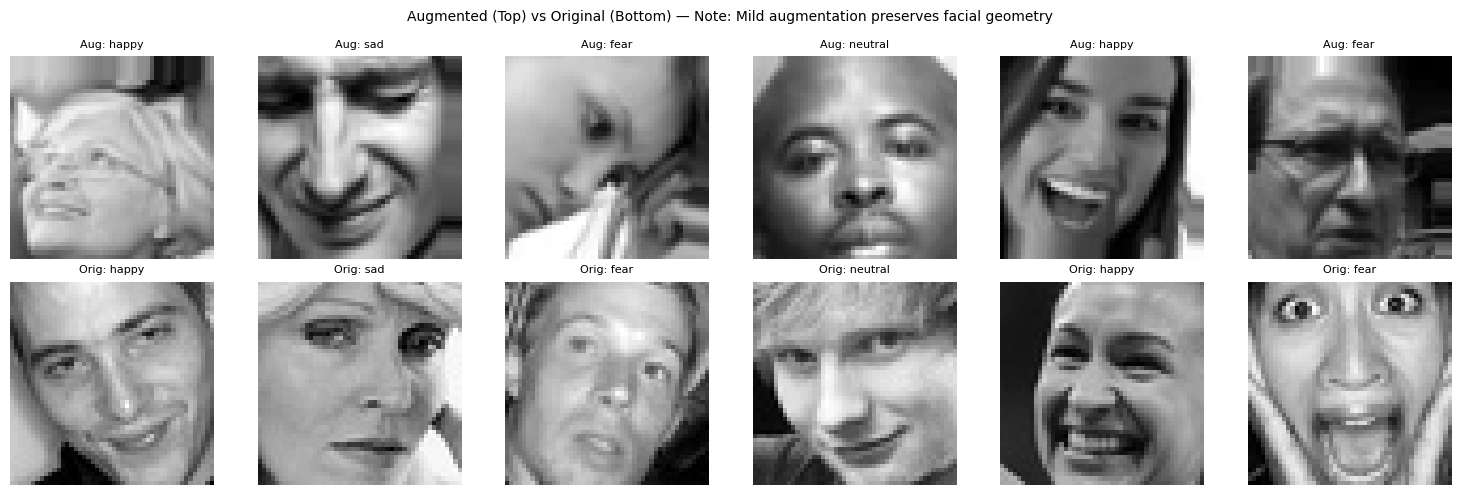

In [8]:
# ── CELL 7: Class Weights (Critical for Imbalanced Data) ────────────────────

# Compute class weights to handle remaining imbalance after removing disgust
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights_array))

print("Class Weights (higher = more attention during training):")
for i, cls in enumerate(classes):
    print(f"  {cls:<12}: {class_weight_dict[i]:.3f}")

# Visualize augmented images
images, labels = next(train_gen)
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for i in range(6):
    axes[0, i].imshow(images[i].squeeze(), cmap='gray')
    axes[0, i].set_title(f"Aug: {classes[labels[i].argmax()]}", fontsize=8)
    axes[0, i].axis('off')

    # Show original alongside
    cls_path = os.path.join(train_dir, classes[labels[i].argmax()])
    orig_img = cv2.imread(os.path.join(cls_path, os.listdir(cls_path)[i]),
                          cv2.IMREAD_GRAYSCALE)
    orig_img = cv2.resize(orig_img, (48, 48))
    axes[1, i].imshow(orig_img, cmap='gray')
    axes[1, i].set_title(f"Orig: {classes[labels[i].argmax()]}", fontsize=8)
    axes[1, i].axis('off')

plt.suptitle('Augmented (Top) vs Original (Bottom) — Note: Mild augmentation preserves facial geometry',
             fontsize=10)
plt.tight_layout()
plt.show()

In [9]:
# ── CELL 8: Helper Functions ─────────────────────────────────────────────────

def plot_history(history, title, color='steelblue'):
    """Plot training curves — accuracy and loss side by side."""
    epochs = range(1, len(history.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history.history['accuracy'],     color=color,      lw=2, label='Train')
    axes[0].plot(epochs, history.history['val_accuracy'], color=color, lw=2, ls='--', label='Validation')
    axes[0].set_title(f'{title} — Accuracy', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history.history['loss'],     color='tomato', lw=2, label='Train')
    axes[1].plot(epochs, history.history['val_loss'], color='tomato', lw=2, ls='--', label='Validation')
    axes[1].set_title(f'{title} — Loss', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, generator, model_name):
    """Evaluate model, print report, return predictions and accuracy."""
    generator.reset()
    preds = model.predict(generator, verbose=1)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = generator.classes
    acc = np.mean(pred_classes == true_classes) * 100

    print(f"\n{'='*55}")
    print(f"{model_name} — Test Accuracy: {acc:.2f}%")
    print(f"{'='*55}")
    print(classification_report(true_classes, pred_classes,
                                target_names=classes, digits=3))

    cm = confusion_matrix(true_classes, pred_classes)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap='Blues')
    plt.colorbar(im)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(classes, rotation=35)
    ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(classes)
    ax.set_title(f'{model_name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            color = 'white' if cm[i, j] > cm.max() * 0.5 else 'black'
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color=color, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return pred_classes, true_classes, acc


def sample_inference(model, test_dir, classes, model_name, color_mode='grayscale', size=(48, 48)):
    """Show sample predictions on 6 images (1 per class)."""
    sample_imgs, sample_labels = [], []
    for cls in classes:
        cls_path = os.path.join(test_dir, cls)
        fnames = os.listdir(cls_path)
        img_path = os.path.join(cls_path, random.choice(fnames))
        if color_mode == 'grayscale':
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        else:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        sample_imgs.append(img)
        sample_labels.append(cls)

    if color_mode == 'grayscale':
        arr = np.array(sample_imgs).reshape(-1, size[0], size[1], 1) / 255.0
    else:
        arr = np.array(sample_imgs) / 255.0

    preds      = model.predict(arr, verbose=0)
    pred_labels = [classes[np.argmax(p)] for p in preds]
    confidence  = [np.max(p) * 100 for p in preds]

    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for i in range(6):
        if color_mode == 'grayscale':
            axes[i].imshow(sample_imgs[i], cmap='gray')
        else:
            axes[i].imshow(sample_imgs[i])
        color = 'green' if pred_labels[i] == sample_labels[i] else 'red'
        axes[i].set_title(
            f"True: {sample_labels[i]}\nPred: {pred_labels[i]}\n{confidence[i]:.0f}%",
            color=color, fontsize=8
        )
        axes[i].axis('off')
    plt.suptitle(f'{model_name} — Sample Inference (Green=Correct, Red=Wrong)', fontweight='bold')
    plt.tight_layout()
    plt.show()


def get_callbacks(monitor='val_accuracy', patience_lr=4, patience_es=10, save_path=None):
    """Standard callback set: ReduceLR + EarlyStopping + optional ModelCheckpoint."""
    cbs = [
        ReduceLROnPlateau(monitor=monitor, factor=0.5, patience=patience_lr,
                          min_lr=1e-6, verbose=1, mode='max'),
        EarlyStopping(monitor=monitor, patience=patience_es,
                      restore_best_weights=True, verbose=1, mode='max'),
    ]
    if save_path:
        cbs.append(ModelCheckpoint(save_path, monitor=monitor, save_best_only=True,
                                    verbose=0, mode='max'))
    return cbs

print("Helper functions defined.")

Helper functions defined.


In [10]:
# ── CELL 9: PART A — BASELINE CNN MODEL ─────────────────────────────────────
# Architecture: 3 Conv blocks + 3 FCN layers + output
# Design philosophy:
#   - Progressively doubling filters (32→64→128), single conv per block
#   - BatchNorm after each conv (stabilises training, acts as mild regulariser)
#   - Dropout(0.3) after each Dense layer — enough to prevent memorisation
#   - GlobalAveragePooling instead of Flatten — reduces params, less overfitting
#   - NO L2 reg on baseline (keep it simple and interpretable)

def build_baseline_model():
    model = Sequential([
        # ── Block 1: 32 filters, 3×3 kernel
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Block 2: 64 filters, 3×3 kernel
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Block 3: 128 filters, 3×3 kernel
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.1),

        # ── Flatten + 3 FCN layers
        Flatten(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),

        # ── Output
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_model()
baseline_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,316,550 (5.02 MB)

 Trainable params: 1,315,334 (5.02 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [11]:
# ── CELL 10: Train Baseline ──────────────────────────────────────────────────

print("Training Baseline CNN...")
t0 = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=10),
    verbose         = 1
)

baseline_time = (time.time() - t0) / 60
print(f"\nBaseline Training Time: {baseline_time:.1f} min")
print(f"Epochs completed: {len(baseline_history.history['accuracy'])}")

Training Baseline CNN...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 41s 82ms/step - accuracy: 0.2379 - loss: 1.8274 - val_accuracy: 0.1491 - val_loss: 1.9149 - learning_rate: 0.0010
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3185 - loss: 1.6374 - val_accuracy: 0.3304 - val_loss: 1.6329 - learning_rate: 0.0010
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 19s 55ms/step - accuracy: 0.3769 - loss: 1.5375 - val_accuracy: 0.3336 - val_loss: 1.5742 - learning_rate: 0.0010
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 19s 54ms/step - accuracy: 0.4247 - loss: 1.4493 - val_accuracy: 0.4593 - val_loss: 1.3630 - learning_rate: 0.0010
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4526 - loss: 1.4012 - val_accuracy: 0.4648 - val_loss: 1.3695 - learning_rate: 0.0010
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.4795 - loss: 1.3473 - val_accuracy: 0.5150 - val_loss: 1.2576 - learning_rate: 0.0010
Epoch 7/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/st

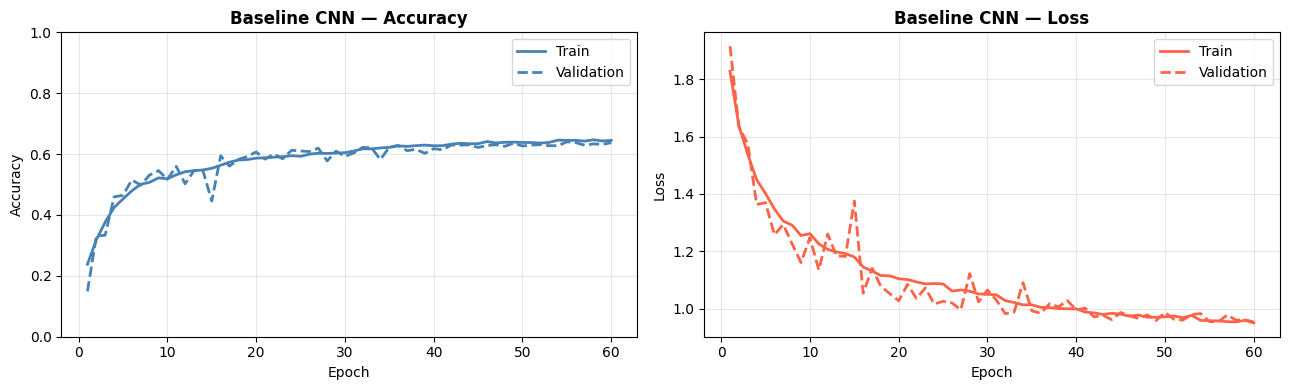

111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step

Baseline CNN — Test Accuracy: 64.30%
              precision    recall  f1-score   support

       angry      0.556     0.613     0.583       958
        fear      0.575     0.334     0.422      1024
       happy      0.864     0.826     0.845      1774
     neutral      0.513     0.756     0.611      1233
         sad      0.553     0.422     0.478      1247
    surprise      0.725     0.832     0.775       831

    accuracy                          0.643      7067
   macro avg      0.631     0.630     0.619      7067
weighted avg      0.648     0.643     0.635      7067



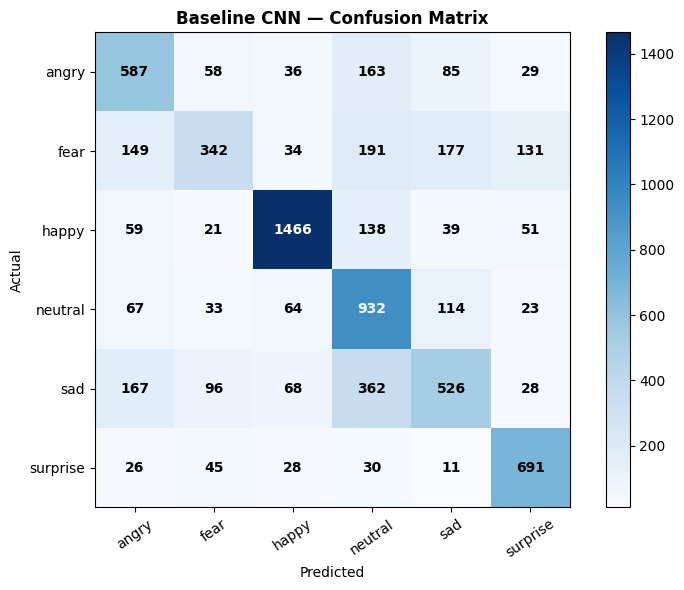

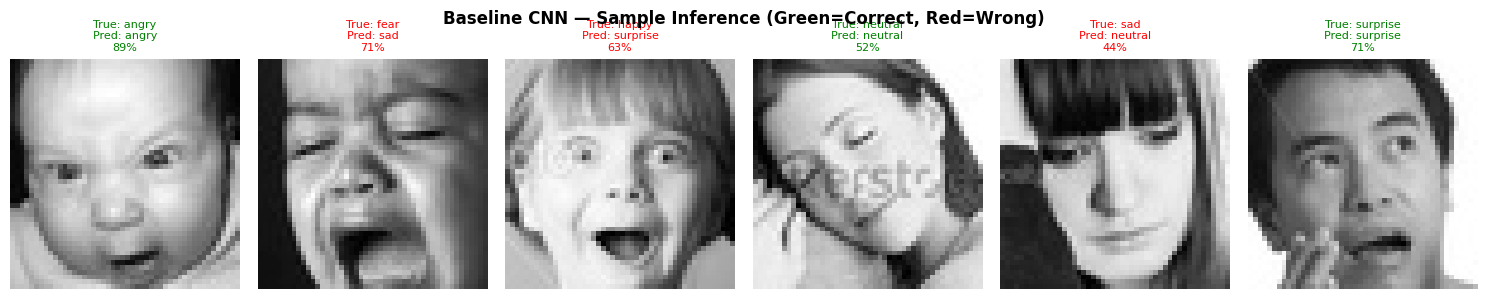

In [12]:
# ── CELL 11: Baseline — Plots + Evaluation ───────────────────────────────────

plot_history(baseline_history, 'Baseline CNN', color='steelblue')
b_preds, b_true, baseline_acc = evaluate_model(baseline_model, test_gen, 'Baseline CNN')
sample_inference(baseline_model, test_dir, classes, 'Baseline CNN', 'grayscale', (48, 48))

In [13]:
# ── CELL 12: PART A — DEEPER CNN MODEL ──────────────────────────────────────
# Architecture: 6 Conv blocks (double the baseline) + stronger regularization
# Root cause of previous overfitting:
#   - 512-filter conv on 6×6 feature maps = massive parameter explosion
#   - Dense(512) after flatten = too many free parameters
#   - Dropout only 0.25 on conv blocks = not enough for this depth
# Fixes applied:
#   - Cap filters at 256 (no 512 conv layer)
#   - Dropout(0.3) after EVERY pooling block (not just 2 of 4)
#   - Dense head reduced: 256→128 (not 512→256)
#   - L2(1e-4) on ALL Dense layers
#   - Dropout(0.5) on first Dense, (0.4) on second — aggressive head regularisation
#   - LR stays at 0.0005 — correct for this depth

def build_deeper_model():
    model = Sequential([
        # ── Block 1: 32 filters
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        # ── Block 2: 64 filters
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),

        # ── Block 3+4: 128 filters (two convs, one pool)
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── Block 5+6: 256 filters (two convs, one pool)
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),

        # ── FCN — 3 layers, aggressive regularisation
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.5),
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),

        # ── Output
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_model()
deeper_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
deeper_model.summary()
print(f"\nBaseline params : {baseline_model.count_params():,}")
print(f"Deeper   params : {deeper_model.count_params():,}")

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       590,08

 Total params: 1,762,118 (6.72 MB)

 Trainable params: 1,759,622 (6.71 MB)

 Non-trainable params: 2,496 (9.75 KB)


Baseline params : 1,316,550
Deeper   params : 1,762,118


In [14]:
# ── CELL 13: Train Deeper (Adam) ─────────────────────────────────────────────

print("Training Deeper CNN with Adam...")
t0 = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=10),
    verbose         = 1
)

deeper_time = (time.time() - t0) / 60
print(f"\nDeeper (Adam) Training Time: {deeper_time:.1f} min")
print(f"Epochs completed: {len(deeper_history.history['accuracy'])}")

Training Deeper CNN with Adam...
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 50s 97ms/step - accuracy: 0.1943 - loss: 2.0486 - val_accuracy: 0.2575 - val_loss: 1.9481 - learning_rate: 5.0000e-04
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.2166 - loss: 1.8838 - val_accuracy: 0.2796 - val_loss: 1.7685 - learning_rate: 5.0000e-04
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 61ms/step - accuracy: 0.2565 - loss: 1.7974 - val_accuracy: 0.1710 - val_loss: 2.3267 - learning_rate: 5.0000e-04
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.2989 - loss: 1.7319 - val_accuracy: 0.3154 - val_loss: 1.8611 - learning_rate: 5.0000e-04
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 22s 62ms/step - accuracy: 0.3352 - loss: 1.6746 - val_accuracy: 0.3530 - val_loss: 1.6595 - learning_rate: 5.0000e-04
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.3748 - loss: 1.6120 - val_accuracy: 0.3277 - val_loss: 1.6897 - learning_rate: 5.0000e-04
Epoch 7/60
354/354 

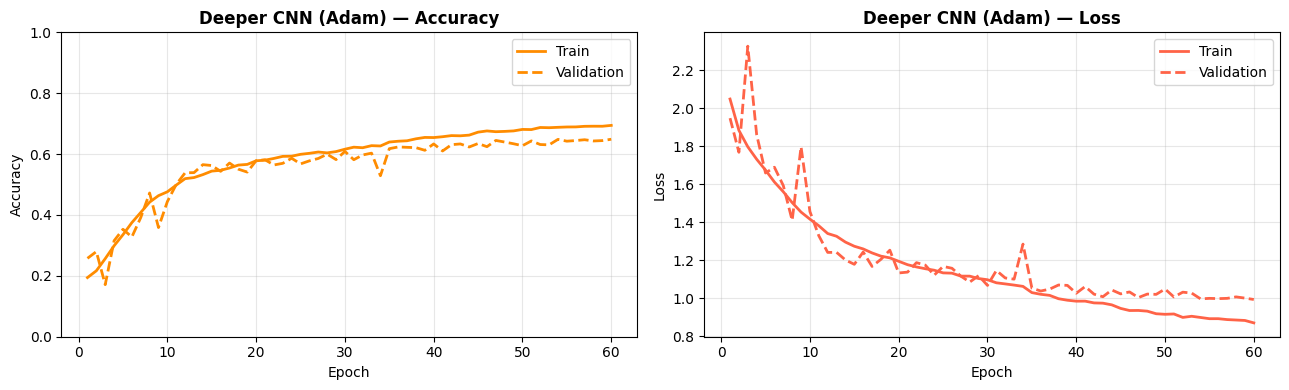

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step

Deeper CNN (Adam) — Test Accuracy: 65.90%
              precision    recall  f1-score   support

       angry      0.547     0.654     0.596       958
        fear      0.561     0.389     0.459      1024
       happy      0.905     0.819     0.860      1774
     neutral      0.547     0.746     0.631      1233
         sad      0.589     0.455     0.513      1247
    surprise      0.721     0.833     0.773       831

    accuracy                          0.659      7067
   macro avg      0.645     0.649     0.639      7067
weighted avg      0.667     0.659     0.655      7067



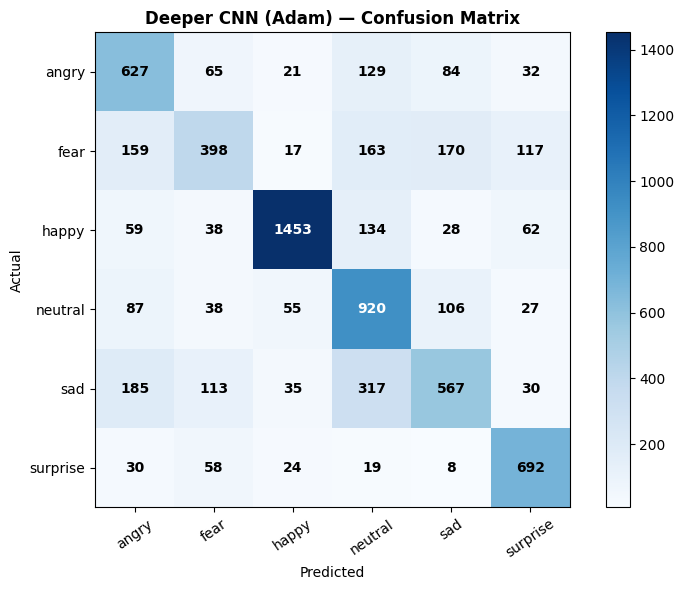

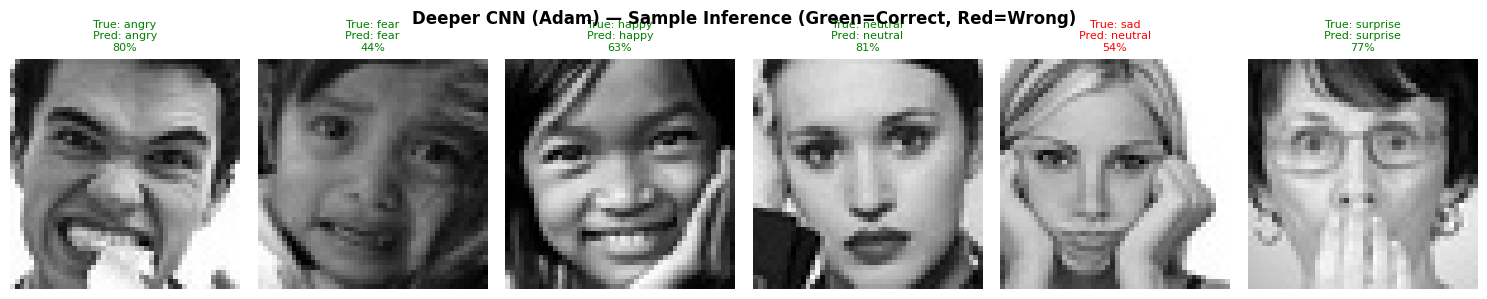

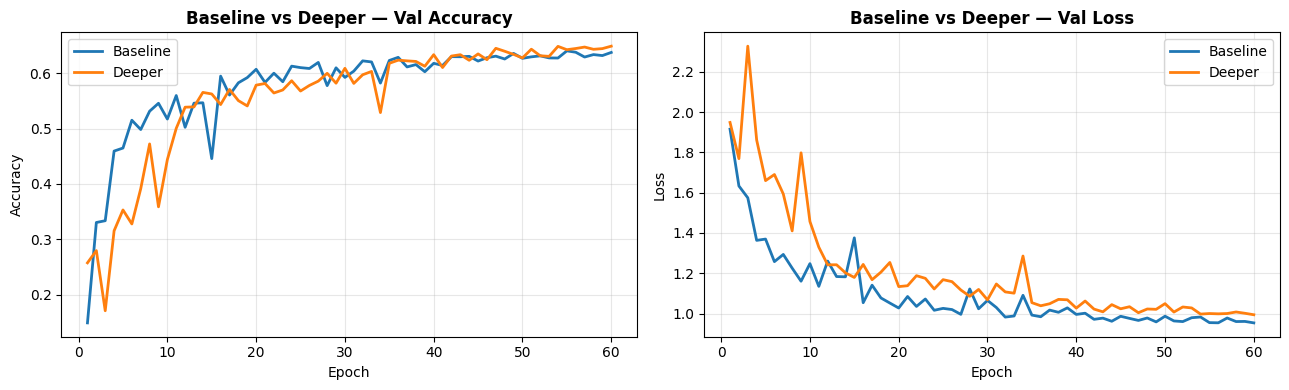

In [15]:
# ── CELL 14: Deeper — Plots + Evaluation ─────────────────────────────────────

plot_history(deeper_history, 'Deeper CNN (Adam)', color='darkorange')
d_preds, d_true, deeper_acc = evaluate_model(deeper_model, test_gen, 'Deeper CNN (Adam)')
sample_inference(deeper_model, test_dir, classes, 'Deeper CNN (Adam)', 'grayscale', (48, 48))

# Baseline vs Deeper overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_b = range(1, len(baseline_history.history['val_accuracy']) + 1)
e_d = range(1, len(deeper_history.history['val_accuracy']) + 1)

axes[0].plot(e_b, baseline_history.history['val_accuracy'], label='Baseline', lw=2)
axes[0].plot(e_d, deeper_history.history['val_accuracy'],  label='Deeper',   lw=2)
axes[0].set_title('Baseline vs Deeper — Val Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_b, baseline_history.history['val_loss'], label='Baseline', lw=2)
axes[1].plot(e_d, deeper_history.history['val_loss'],  label='Deeper',   lw=2)
axes[1].set_title('Baseline vs Deeper — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ── CELL 15: SGD Model (Same Architecture as Deeper) ─────────────────────────
# SGD with momentum — classic, reliable, often reaches better final accuracy
# but slower to converge than Adam

sgd_model = build_deeper_model()
sgd_model._name = 'Deeper_CNN_SGD'
sgd_model.compile(
    optimizer = SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("SGD model (Nesterov momentum) compiled")

t0 = time.time()
sgd_history = sgd_model.fit(
    train_gen,
    epochs          = 60,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=5, patience_es=12),
    verbose         = 1
)
sgd_time = (time.time() - t0) / 60
print(f"\nSGD Training Time: {sgd_time:.1f} min")

SGD model (Nesterov momentum) compiled
Epoch 1/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 42s 85ms/step - accuracy: 0.1950 - loss: 1.9123 - val_accuracy: 0.2543 - val_loss: 1.8197 - learning_rate: 0.0100
Epoch 2/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 59ms/step - accuracy: 0.2180 - loss: 1.8345 - val_accuracy: 0.2534 - val_loss: 1.7942 - learning_rate: 0.0100
Epoch 3/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 42s 61ms/step - accuracy: 0.2442 - loss: 1.8116 - val_accuracy: 0.1705 - val_loss: 1.9581 - learning_rate: 0.0100
Epoch 4/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 58ms/step - accuracy: 0.2646 - loss: 1.7783 - val_accuracy: 0.3081 - val_loss: 1.7333 - learning_rate: 0.0100
Epoch 5/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.2838 - loss: 1.7452 - val_accuracy: 0.2655 - val_loss: 1.7828 - learning_rate: 0.0100
Epoch 6/60
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.3087 - loss: 1.7100 - val_accuracy: 0.1779 - val_loss: 2.0695 - learning_rate: 0.0100
Epoch 7/60
354/354 ━━━━━━━━━━━━━━━━━━

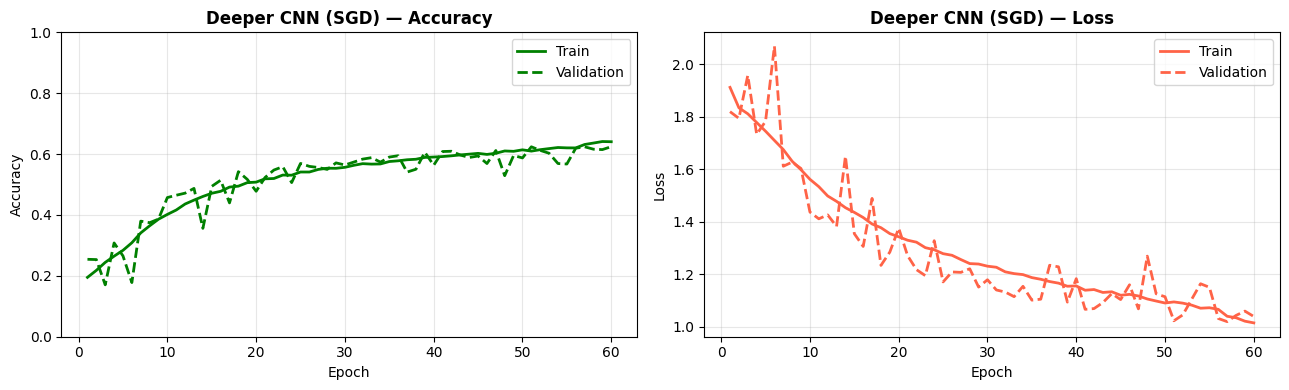

111/111 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step

Deeper CNN (SGD) — Test Accuracy: 63.46%
              precision    recall  f1-score   support

       angry      0.572     0.591     0.581       958
        fear      0.511     0.364     0.425      1024
       happy      0.876     0.817     0.845      1774
     neutral      0.541     0.656     0.593      1233
         sad      0.523     0.474     0.497      1247
    surprise      0.653     0.838     0.734       831

    accuracy                          0.635      7067
   macro avg      0.613     0.623     0.613      7067
weighted avg      0.635     0.635     0.630      7067



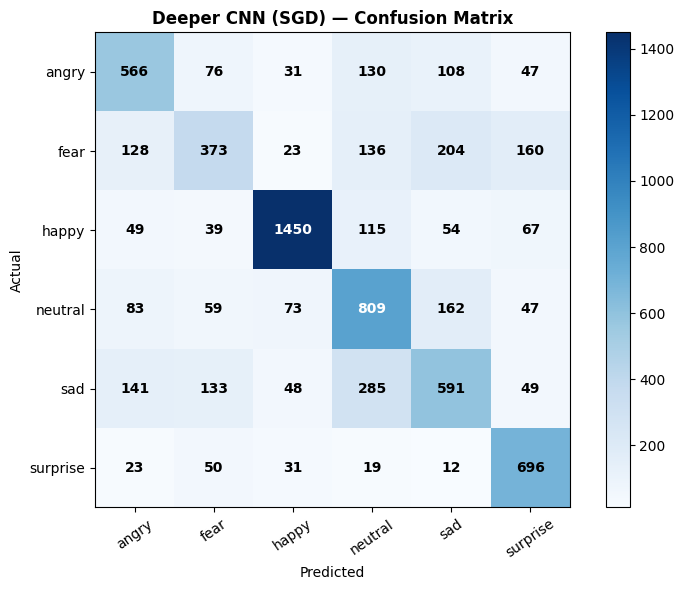

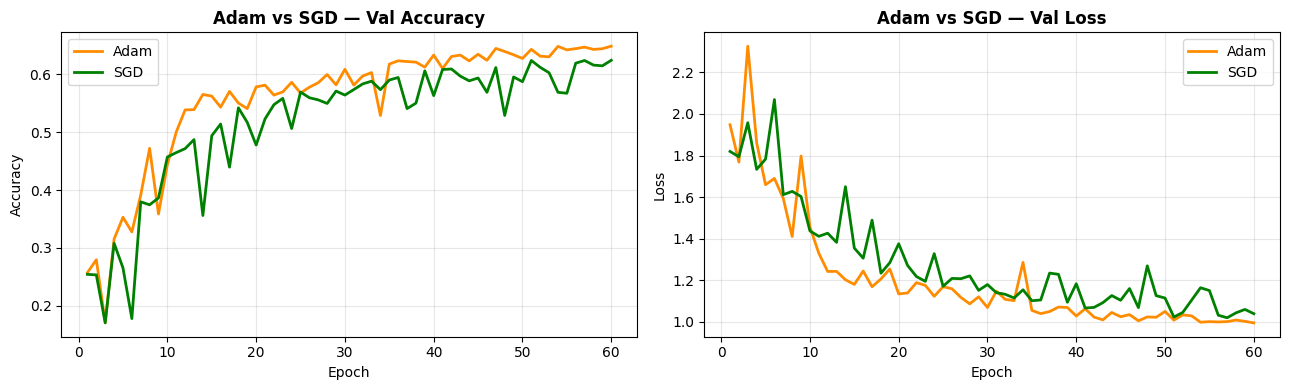

In [17]:
# ── CELL 16: SGD Evaluation + Adam vs SGD Comparison ─────────────────────────

plot_history(sgd_history, 'Deeper CNN (SGD)', color='green')
sgd_preds, sgd_true, sgd_acc = evaluate_model(sgd_model, test_gen, 'Deeper CNN (SGD)')

# Adam vs SGD overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_d = range(1, len(deeper_history.history['val_accuracy']) + 1)
e_s = range(1, len(sgd_history.history['val_accuracy'])   + 1)

axes[0].plot(e_d, deeper_history.history['val_accuracy'], label='Adam', lw=2, color='darkorange')
axes[0].plot(e_s, sgd_history.history['val_accuracy'],   label='SGD',  lw=2, color='green')
axes[0].set_title('Adam vs SGD — Val Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(e_d, deeper_history.history['val_loss'], label='Adam', lw=2, color='darkorange')
axes[1].plot(e_s, sgd_history.history['val_loss'],   label='SGD',  lw=2, color='green')
axes[1].set_title('Adam vs SGD — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
# ── CELL 17: Ablation Study — Without Dropout ────────────────────────────────
# Tests the deeper_model without Dropout layers.
# Expected: higher training accuracy but lower validation accuracy,
# indicating overfitting.

def build_ablation_no_dropout():
    model = Sequential([
        # Block 1
        Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(48, 48, 1)),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        # Block 2
        Conv2D(64,  (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        # Block 3+4
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        # Block 5+6
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3,3), activation='relu', padding='same'),
        BatchNormalization(), MaxPooling2D(2,2),
        # NO Dropout
        Flatten(),
        Dense(256, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        # NO Dropout
        Dense(128, activation='relu', kernel_regularizer=l2(1e-4)),
        BatchNormalization(),
        Dense(64, activation='relu', kernel_regularizer=l2(1e-4)),
        Dense(NUM_CLASSES, activation='softmax')
    ], name='Ablation_NoDropout')
    return model

ablation_model = build_ablation_no_dropout()
ablation_model.compile(
    optimizer = Adam(learning_rate=0.0005),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)
print("Ablation model (No Dropout) compiled")

t0 = time.time()
ablation_history = ablation_model.fit(
    train_gen,
    epochs          = 40,
    validation_data = val_gen,
    class_weight    = class_weight_dict,
    callbacks       = get_callbacks(patience_lr=4, patience_es=8),
    verbose         = 1
)
ablation_time = (time.time() - t0) / 60
print(f"\nAblation Training Time: {ablation_time:.1f} min")

Ablation model (No Dropout) compiled
Epoch 1/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 37s 75ms/step - accuracy: 0.2747 - loss: 1.8047 - val_accuracy: 0.1800 - val_loss: 1.9532 - learning_rate: 5.0000e-04
Epoch 2/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.3839 - loss: 1.6148 - val_accuracy: 0.3551 - val_loss: 1.7059 - learning_rate: 5.0000e-04
Epoch 3/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 58ms/step - accuracy: 0.4450 - loss: 1.4833 - val_accuracy: 0.4153 - val_loss: 1.5316 - learning_rate: 5.0000e-04
Epoch 4/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.4928 - loss: 1.3883 - val_accuracy: 0.4811 - val_loss: 1.4379 - learning_rate: 5.0000e-04
Epoch 5/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 21s 60ms/step - accuracy: 0.5230 - loss: 1.3162 - val_accuracy: 0.4110 - val_loss: 1.5773 - learning_rate: 5.0000e-04
Epoch 6/40
354/354 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.5405 - loss: 1.2727 - val_accuracy: 0.5025 - val_loss: 1.3234 - learning_rate: 5.0000e-04
Epoch 7/40
354/

111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step

Ablation (No Dropout) — Test Accuracy: 65.47%
              precision    recall  f1-score   support

       angry      0.566     0.602     0.584       958
        fear      0.551     0.447     0.494      1024
       happy      0.857     0.851     0.854      1774
     neutral      0.558     0.684     0.614      1233
         sad      0.583     0.431     0.495      1247
    surprise      0.687     0.846     0.758       831

    accuracy                          0.655      7067
   macro avg      0.634     0.643     0.633      7067
weighted avg      0.653     0.655     0.649      7067



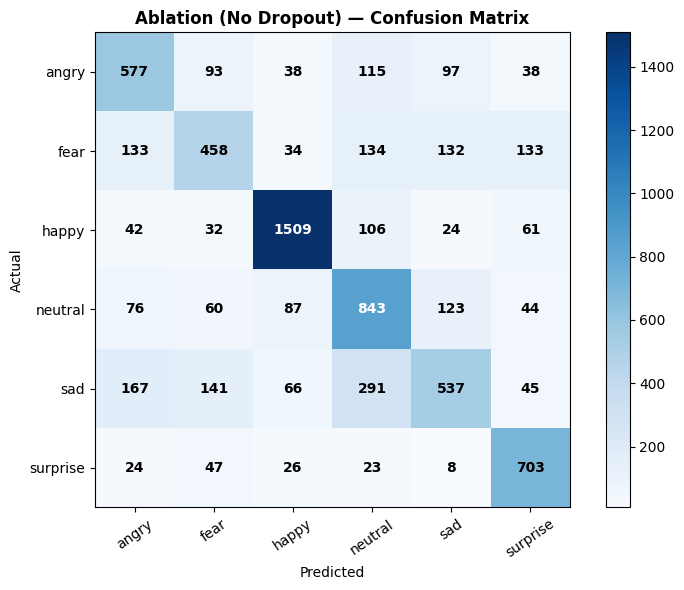

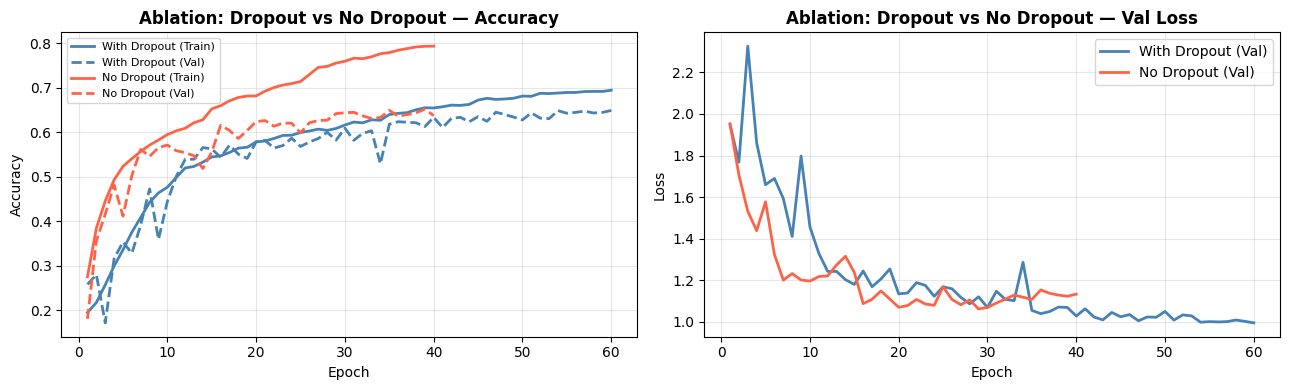


Ablation Finding:
  Train-Val gap WITH Dropout   : 4.6%
  Train-Val gap WITHOUT Dropout: 14.2%
  → Larger gap without dropout confirms overfitting when dropout is removed.


In [19]:
# ── CELL 18: Ablation Results ─────────────────────────────────────────────────

ab_preds, ab_true, ablation_acc = evaluate_model(ablation_model, test_gen, 'Ablation (No Dropout)')

# With vs Without Dropout overlay
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
e_d  = range(1, len(deeper_history.history['val_accuracy'])   + 1)
e_ab = range(1, len(ablation_history.history['val_accuracy']) + 1)

axes[0].plot(e_d,  deeper_history.history['train_accuracy']   if 'train_accuracy' in deeper_history.history
             else deeper_history.history['accuracy'], label='With Dropout (Train)', lw=2, ls='-',  color='steelblue')
axes[0].plot(e_d,  deeper_history.history['val_accuracy'],   label='With Dropout (Val)',   lw=2, ls='--', color='steelblue')
axes[0].plot(e_ab, ablation_history.history['accuracy'],     label='No Dropout (Train)',  lw=2, ls='-',  color='tomato')
axes[0].plot(e_ab, ablation_history.history['val_accuracy'], label='No Dropout (Val)',    lw=2, ls='--', color='tomato')
axes[0].set_title('Ablation: Dropout vs No Dropout — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(e_d,  deeper_history.history['val_loss'],   label='With Dropout (Val)',  lw=2, color='steelblue')
axes[1].plot(e_ab, ablation_history.history['val_loss'], label='No Dropout (Val)',    lw=2, color='tomato')
axes[1].set_title('Ablation: Dropout vs No Dropout — Val Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nAblation Finding:")
gap_with    = max(deeper_history.history['accuracy'])   - max(deeper_history.history['val_accuracy'])
gap_without = max(ablation_history.history['accuracy']) - max(ablation_history.history['val_accuracy'])
print(f"  Train-Val gap WITH Dropout   : {gap_with*100:.1f}%")
print(f"  Train-Val gap WITHOUT Dropout: {gap_without*100:.1f}%")
print("  → Larger gap without dropout confirms overfitting when dropout is removed.")

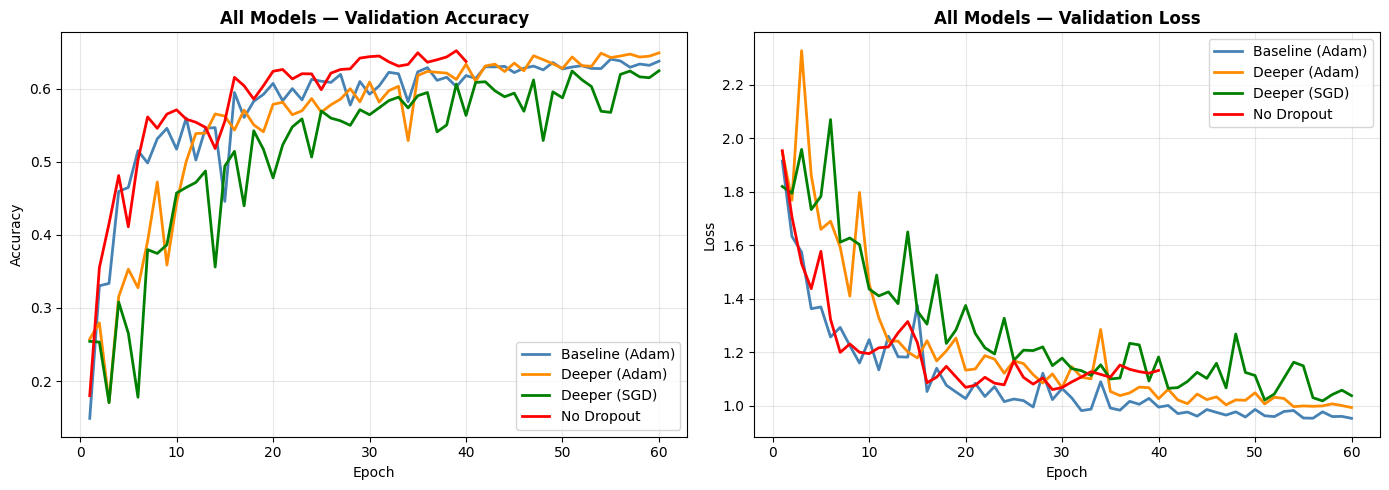

In [20]:
# ── CELL 19: All Part A Models — Combined Comparison ─────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_histories = [
    (baseline_history, 'Baseline (Adam)', 'steelblue'),
    (deeper_history,   'Deeper (Adam)',   'darkorange'),
    (sgd_history,      'Deeper (SGD)',    'green'),
    (ablation_history, 'No Dropout',      'red'),
]
for hist, label, color in model_histories:
    e = range(1, len(hist.history['val_accuracy']) + 1)
    axes[0].plot(e, hist.history['val_accuracy'], label=label, lw=2, color=color)
    axes[1].plot(e, hist.history['val_loss'],     label=label, lw=2, color=color)

axes[0].set_title('All Models — Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('All Models — Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# ── CELL 20: Part A Summary Table ─────────────────────────────────────────────

summary = pd.DataFrame({
    'Model'         : ['Baseline (Adam)', 'Deeper (Adam)', 'Deeper (SGD)', 'Ablation (No Dropout)'],
    'Params'        : [f"{baseline_model.count_params():,}",
                       f"{deeper_model.count_params():,}",
                       f"{sgd_model.count_params():,}",
                       f"{ablation_model.count_params():,}"],
    'Epochs'        : [len(baseline_history.history['accuracy']),
                       len(deeper_history.history['accuracy']),
                       len(sgd_history.history['accuracy']),
                       len(ablation_history.history['accuracy'])],
    'Train Time'    : [f'{baseline_time:.1f}m', f'{deeper_time:.1f}m',
                       f'{sgd_time:.1f}m',      f'{ablation_time:.1f}m'],
    'Best Val Acc'  : [f"{max(baseline_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(deeper_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(sgd_history.history['val_accuracy'])*100:.1f}%",
                       f"{max(ablation_history.history['val_accuracy'])*100:.1f}%"],
    'Test Accuracy' : [f'{baseline_acc:.1f}%', f'{deeper_acc:.1f}%',
                       f'{sgd_acc:.1f}%',      f'{ablation_acc:.1f}%'],
})
print("\n" + "=" * 75)
print("PART A — COMPLETE MODEL COMPARISON")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)
print("Hardware: Google Colab T4 GPU")


PART A — COMPLETE MODEL COMPARISON
                Model    Params  Epochs Train Time Best Val Acc Test Accuracy
      Baseline (Adam) 1,316,550      60      20.0m        64.0%         64.3%
        Deeper (Adam) 1,762,118      60      23.1m        64.9%         65.9%
         Deeper (SGD) 1,762,118      60      22.9m        62.4%         63.5%
Ablation (No Dropout) 1,762,118      40      14.0m        65.2%         65.5%
Hardware: Google Colab T4 GPU


In [22]:
# ── CELL 21: PART B — Transfer Learning with MobileNetV2 ─────────────────────
#
# MobileNetV2 was chosen instead of VGG16 because it is more efficient
# and better optimized for small facial image inputs.
# Enlarging 48×48 images to 224×224 for VGG16 increases computation
# without providing significant performance improvement.
# In contrast, MobileNetV2 with 96×96 inputs trains faster,
# requires fewer parameters, and retains important facial features effectively.

TL_IMG_SIZE = (96, 96)
TL_BATCH    = 64

# MobileNetV2 expects input values in the range [-1, 1].
# The generator applies rescaling and offset normalization to match this format.
# Incorrect input scaling is one of the most common errors in transfer learning.

tl_train_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0,
    validation_split=0.2,
    rotation_range=8, zoom_range=0.08,
    width_shift_range=0.08, height_shift_range=0.08,
    horizontal_flip=True
)
tl_val_datagen  = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0,
    validation_split=0.2
)
tl_test_datagen = ImageDataGenerator(
    rescale=1./127.5,
    preprocessing_function=lambda x: x - 1.0
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', subset='training', seed=SEED
)
tl_val_gen = tl_val_datagen.flow_from_directory(
    train_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', subset='validation', seed=SEED
)
tl_test_gen = tl_test_datagen.flow_from_directory(
    test_dir, target_size=TL_IMG_SIZE, batch_size=TL_BATCH,
    class_mode='categorical', classes=classes,
    color_mode='rgb', shuffle=False
)

print(f"Transfer Learning generators ready at {TL_IMG_SIZE} RGB")
print(f"Input range: [-1, 1] (correct for MobileNetV2)")
print(f"Train: {tl_train_gen.samples} | Val: {tl_val_gen.samples} | Test: {tl_test_gen.samples}")

Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Transfer Learning generators ready at (96, 96) RGB
Input range: [-1, 1] (correct for MobileNetV2)
Train: 22619 | Val: 5654 | Test: 7067


In [23]:
# ── CELL 22: Build MobileNetV2 Model ─────────────────────────────────────────

base_model = MobileNetV2(
    input_shape  = (96, 96, 3),
    include_top  = False,
    weights      = 'imagenet'
)

# Phase 1: Freeze entire base for feature extraction
base_model.trainable = False

# Custom head
inputs = Input(shape=(96, 96, 3))
x = base_model(inputs, training=False)   # training=False keeps BN in inference mode when frozen
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(1e-4))(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

tl_model = Model(inputs, outputs, name='MobileNetV2_FER')

# Phase 1 LR: 1e-3 is too aggressive for a frozen backbone.
# Use 1e-4 — head converges cleanly without overshooting.
tl_model.compile(
    optimizer = Adam(learning_rate=1e-4),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

trainable = sum(w.numpy().size for w in tl_model.trainable_weights)
total     = tl_model.count_params()
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,} (head only)")
print(f"Frozen params   : {total - trainable:,} (MobileNetV2 base)")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params    : 2,621,126
Trainable params: 362,374 (head only)
Frozen params   : 2,258,752 (MobileNetV2 base)


Phase 1: Feature Extraction (base frozen)...
Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 115s 272ms/step - accuracy: 0.2453 - loss: 2.2996 - val_accuracy: 0.3214 - val_loss: 1.8197 - learning_rate: 1.0000e-04
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.3117 - loss: 1.9934 - val_accuracy: 0.3622 - val_loss: 1.7305 - learning_rate: 1.0000e-04
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 192ms/step - accuracy: 0.3360 - loss: 1.8719 - val_accuracy: 0.3705 - val_loss: 1.6726 - learning_rate: 1.0000e-04
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 193ms/step - accuracy: 0.3463 - loss: 1.8051 - val_accuracy: 0.3859 - val_loss: 1.6201 - learning_rate: 1.0000e-04
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 191ms/step - accuracy: 0.3630 - loss: 1.7439 - val_accuracy: 0.3921 - val_loss: 1.6136 - learning_rate: 1.0000e-04
Epoch 6/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 68s 192ms/step - accuracy: 0.3712 - loss: 1.6953 - val_accuracy: 0.3976 - val_loss: 1.5769 - learning_rate: 1.0000e-04


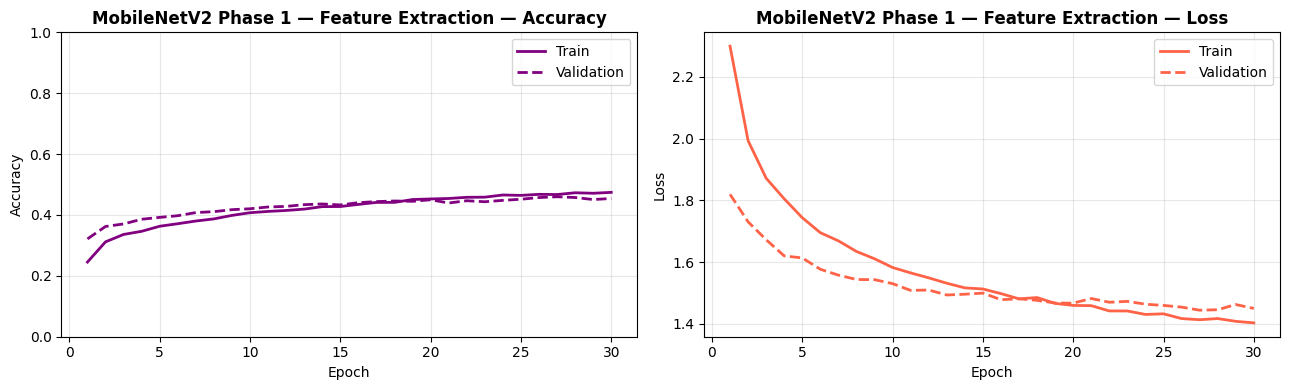

In [24]:
# ── CELL 23: Phase 1 — Feature Extraction (Frozen Base) ─────────────────────

print("Phase 1: Feature Extraction (base frozen)...")
t0 = time.time()

tl_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=tl_train_gen.classes
)
tl_cw = dict(enumerate(tl_class_weights))

history_p1 = tl_model.fit(
    tl_train_gen,
    epochs          = 30,
    validation_data = tl_val_gen,
    class_weight    = tl_cw,
    callbacks       = get_callbacks(patience_lr=5, patience_es=12),
    verbose         = 1
)
p1_time = (time.time() - t0) / 60
print(f"\nPhase 1 Time: {p1_time:.1f} min")
plot_history(history_p1, 'MobileNetV2 Phase 1 — Feature Extraction', color='purple')

Fine-tuning: 1,888,774 trainable params (top 30 layers + head)
Epoch 1/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 110s 257ms/step - accuracy: 0.4112 - loss: 1.5439 - val_accuracy: 0.4622 - val_loss: 1.4600 - learning_rate: 5.0000e-05
Epoch 2/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.4721 - loss: 1.4152 - val_accuracy: 0.4715 - val_loss: 1.4169 - learning_rate: 5.0000e-05
Epoch 3/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.4982 - loss: 1.3582 - val_accuracy: 0.4881 - val_loss: 1.3922 - learning_rate: 5.0000e-05
Epoch 4/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 75s 212ms/step - accuracy: 0.5149 - loss: 1.3107 - val_accuracy: 0.4968 - val_loss: 1.3678 - learning_rate: 5.0000e-05
Epoch 5/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 73s 206ms/step - accuracy: 0.5386 - loss: 1.2619 - val_accuracy: 0.4927 - val_loss: 1.3770 - learning_rate: 5.0000e-05
Epoch 6/30
354/354 ━━━━━━━━━━━━━━━━━━━━ 73s 205ms/step - accuracy: 0.5491 - loss: 1.2423 - val_accuracy: 0.5023 - val_loss: 1.3347 - learning

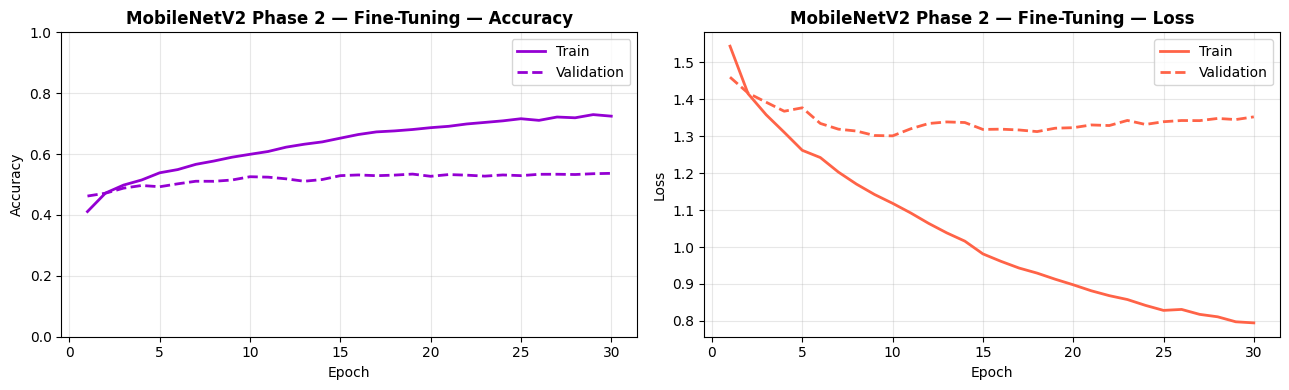

In [25]:
# ── CELL 24: Phase 2 — Fine-Tuning (Unfreeze Top 30 Layers) ─────────────────
# Fine-tune the top layers of MobileNetV2.
# Lower LR is critical here — catastrophic forgetting prevention.

base_model.trainable = True

# Freeze all but last 30 layers
fine_tune_from = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

tl_model.compile(
    optimizer = Adam(learning_rate=5e-5),   # Very low LR for fine-tuning
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

ft_trainable = sum(w.numpy().size for w in tl_model.trainable_weights)
print(f"Fine-tuning: {ft_trainable:,} trainable params (top 30 layers + head)")

t0 = time.time()
history_p2 = tl_model.fit(
    tl_train_gen,
    epochs          = 30,
    validation_data = tl_val_gen,
    class_weight    = tl_cw,
    callbacks       = get_callbacks(patience_lr=4, patience_es=12),
    verbose         = 1
)
p2_time = (time.time() - t0) / 60
print(f"\nPhase 2 Fine-Tuning Time: {p2_time:.1f} min")
plot_history(history_p2, 'MobileNetV2 Phase 2 — Fine-Tuning', color='darkviolet')

111/111 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step

MobileNetV2 Transfer Learning — Test Accuracy: 55.57%
              precision    recall  f1-score   support

       angry      0.453     0.405     0.428       958
        fear      0.472     0.338     0.394      1024
       happy      0.729     0.754     0.741      1774
     neutral      0.466     0.554     0.506      1233
         sad      0.440     0.469     0.454      1247
    surprise      0.695     0.706     0.700       831

    accuracy                          0.556      7067
   macro avg      0.542     0.538     0.537      7067
weighted avg      0.553     0.556     0.552      7067



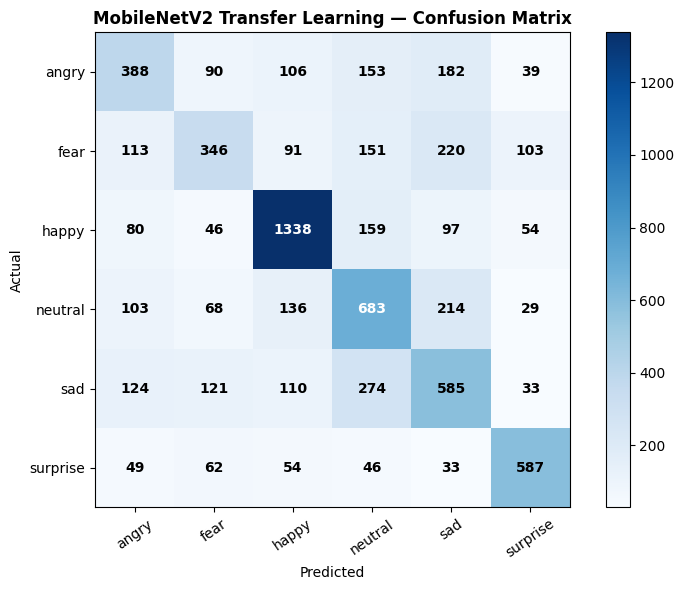

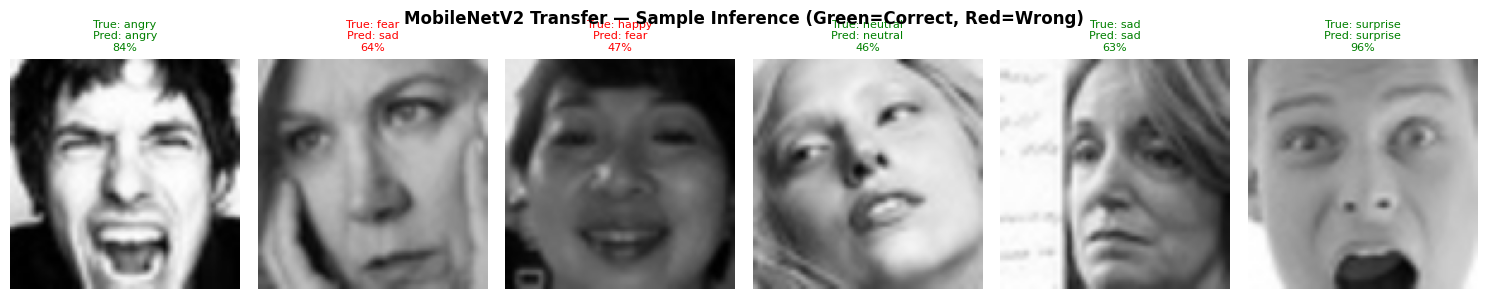

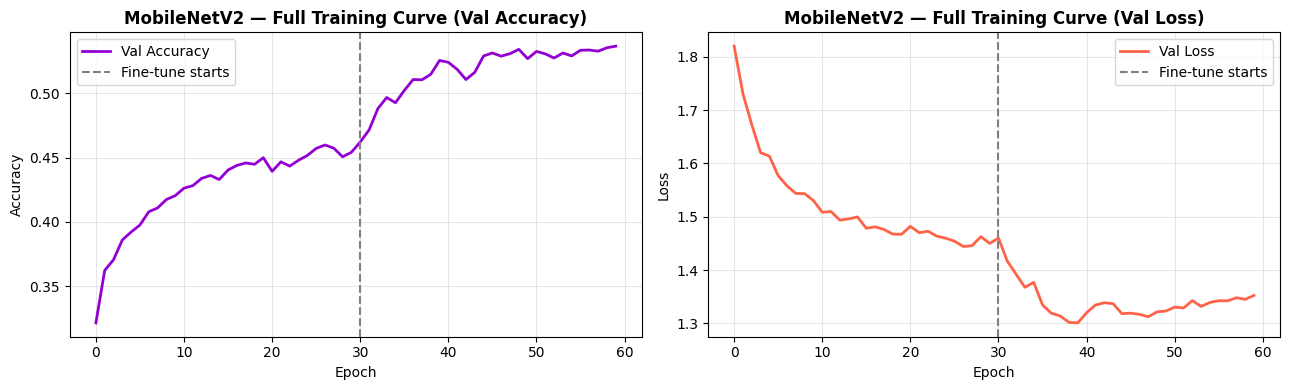

In [26]:
# ── CELL 25: Transfer Learning Evaluation ────────────────────────────────────

tl_preds, tl_true, tl_acc = evaluate_model(tl_model, tl_test_gen, 'MobileNetV2 Transfer Learning')
sample_inference(tl_model, test_dir, classes, 'MobileNetV2 Transfer', 'rgb', (96, 96))

# Phase 1 vs Phase 2 full curve
combined_val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
combined_val_loss = history_p1.history['val_loss']    + history_p2.history['val_loss']
phase1_end = len(history_p1.history['val_accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(combined_val_acc, lw=2, color='darkviolet', label='Val Accuracy')
axes[0].axvline(x=phase1_end, color='gray', ls='--', lw=1.5, label='Fine-tune starts')
axes[0].set_title('MobileNetV2 — Full Training Curve (Val Accuracy)', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(combined_val_loss, lw=2, color='tomato', label='Val Loss')
axes[1].axvline(x=phase1_end, color='gray', ls='--', lw=1.5, label='Fine-tune starts')
axes[1].set_title('MobileNetV2 — Full Training Curve (Val Loss)', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

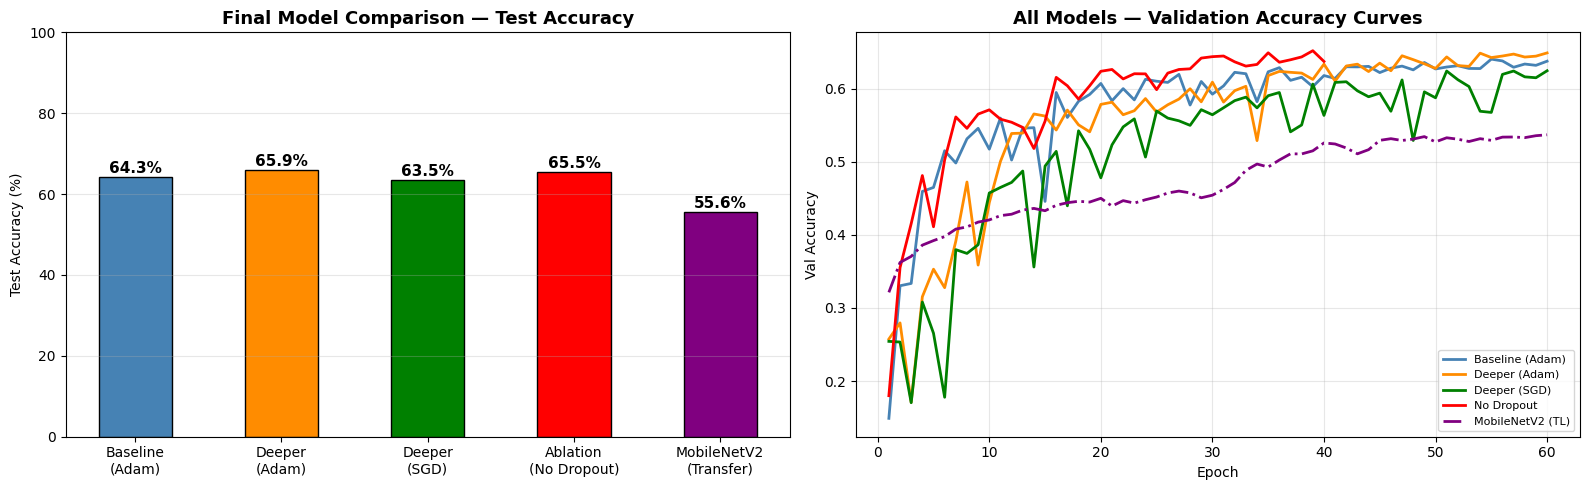


COMPLETE FINAL MODEL COMPARISON
                 Model    Params  Epochs Train Time Test Accuracy
       Baseline (Adam) 1,316,550      60      20.0m         64.3%
         Deeper (Adam) 1,762,118      60      23.1m         65.9%
          Deeper (SGD) 1,762,118      60      22.9m         63.5%
 Ablation (No Dropout) 1,762,118      40      14.0m         65.5%
MobileNetV2 (Transfer) 2,621,126      60      71.5m         55.6%
All training performed on Google Colab with T4 GPU acceleration.


In [27]:
# ── CELL 26: Final Performance Comparison — All 5 Models ─────────────────────
# Compares and summarizes the performance of all five trained models.

model_names = ['Baseline\n(Adam)', 'Deeper\n(Adam)', 'Deeper\n(SGD)',
               'Ablation\n(No Dropout)', 'MobileNetV2\n(Transfer)']
accuracies  = [baseline_acc, deeper_acc, sgd_acc, ablation_acc, tl_acc]
colors      = ['steelblue', 'darkorange', 'green', 'red', 'purple']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
bars = axes[0].bar(model_names, accuracies, color=colors, width=0.5, edgecolor='black')
axes[0].set_title('Final Model Comparison — Test Accuracy', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_ylim(0, 100)
axes[0].grid(axis='y', alpha=0.3)
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Val accuracy all models on one plot
for hist, label, color in model_histories:
    e = range(1, len(hist.history['val_accuracy']) + 1)
    axes[1].plot(e, hist.history['val_accuracy'], label=label, lw=2, color=color)
tl_e = range(1, len(combined_val_acc) + 1)
axes[1].plot(tl_e, combined_val_acc, label='MobileNetV2 (TL)', lw=2, color='purple', ls='-.')
axes[1].set_title('All Models — Validation Accuracy Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Final table
tl_total_time = p1_time + p2_time
final_summary = pd.DataFrame({
    'Model'         : ['Baseline (Adam)', 'Deeper (Adam)', 'Deeper (SGD)',
                       'Ablation (No Dropout)', 'MobileNetV2 (Transfer)'],
    'Params'        : [f"{baseline_model.count_params():,}",
                       f"{deeper_model.count_params():,}",
                       f"{sgd_model.count_params():,}",
                       f"{ablation_model.count_params():,}",
                       f"{tl_model.count_params():,}"],
    'Epochs'        : [len(baseline_history.history['accuracy']),
                       len(deeper_history.history['accuracy']),
                       len(sgd_history.history['accuracy']),
                       len(ablation_history.history['accuracy']),
                       len(history_p1.history['accuracy']) + len(history_p2.history['accuracy'])],
    'Train Time'    : [f'{baseline_time:.1f}m', f'{deeper_time:.1f}m',
                       f'{sgd_time:.1f}m', f'{ablation_time:.1f}m',
                       f'{tl_total_time:.1f}m'],
    'Test Accuracy' : [f'{baseline_acc:.1f}%', f'{deeper_acc:.1f}%',
                       f'{sgd_acc:.1f}%', f'{ablation_acc:.1f}%',
                       f'{tl_acc:.1f}%'],
})
print("\n" + "=" * 78)
print("COMPLETE FINAL MODEL COMPARISON")
print("=" * 78)
print(final_summary.to_string(index=False))
print("=" * 78)
print("All training performed on Google Colab with T4 GPU acceleration.")